<a href="https://colab.research.google.com/github/zhangyingchengqi/Modern-Computer-Vision-with-PyTorch/blob/master/Chapter03/Preparing_our_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 第三章 第四节 preparing our data 准备图像数据集

fashion MNIST

Fashion-MNIST 是一个用于 图像分类 的开源数据集。

由 Zalando（德国时尚电商公司） 在 2017 年发布，作为 MNIST 手写数字集的替代品。

目的：MNIST 太简单了，很多模型轻松达到接近 100% 的准确率，不再能体现算法差异，所以需要一个更有挑战性的“入门级”数据集。

图像大小：28 × 28 像素

图像通道：灰度图（单通道）

总样本数：70,000 张

训练集：60,000 张

测试集：10,000 张

类别数：10 类，每类都是一件衣物

类别标签:  <br />
0 → T-shirt / top（T恤） <br />
1 → Trouser（裤子）   <br />
2 → Pullover（套头衫）  <br />
3 → Dress（连衣裙）  <br />
4 → Coat（外套）  <br />
5 → Sandal（凉鞋）  <br />
6 → Shirt（衬衫）  <br />
7 → Sneaker（运动鞋）  <br />
8 → Bag（包）  <br />
9 → Ankle boot（短靴） <br />

In [1]:
from torchvision import datasets
import torch
data_folder = '~/data/FMNIST' # This can be any directory you want
# to download FMNIST to
fmnist = datasets.FashionMNIST(data_folder, download=True, train=True)

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 203kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.37MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.1MB/s]


In [2]:
tr_images = fmnist.data
tr_targets = fmnist.targets

In [3]:
# 获取训练集标签 (tr_targets) 中的唯一值，也就是类别标签的去重结果
unique_values = tr_targets.unique()

# 打印训练数据集的形状信息：
# tr_images.shape 表示训练图片的维度 (数量, 高, 宽)，例如 (60000, 28, 28)
# tr_targets.shape 表示训练标签的维度，例如 (60000,)
# unique_values 表示标签中去重后的类别编号 (例如 tensor([0,1,2,...,9]))
print(f'tr_images & tr_targets:\n\tX - {tr_images.shape}\n\tY - {tr_targets.shape}\n\tY - Unique Values : {unique_values}')

# 打印任务说明：len(unique_values) 表示类别的数量
# 这里对应 Fashion-MNIST 数据集，一般是 10 个类别
print(f'TASK:\n\t{len(unique_values)} class Classification')

# 打印数据集的类别名称，fmnist.classes 是一个包含类别名字的列表
# 比如 ["T-shirt/top", "Trouser", "Pullover", "Dress", ... "Ankle boot"]
print(f'UNIQUE CLASSES:\n\t{fmnist.classes}')

tr_images & tr_targets:
	X - torch.Size([60000, 28, 28])
	Y - torch.Size([60000])
	Y - Unique Values : tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
TASK:
	10 class Classification
UNIQUE CLASSES:
	['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [4]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

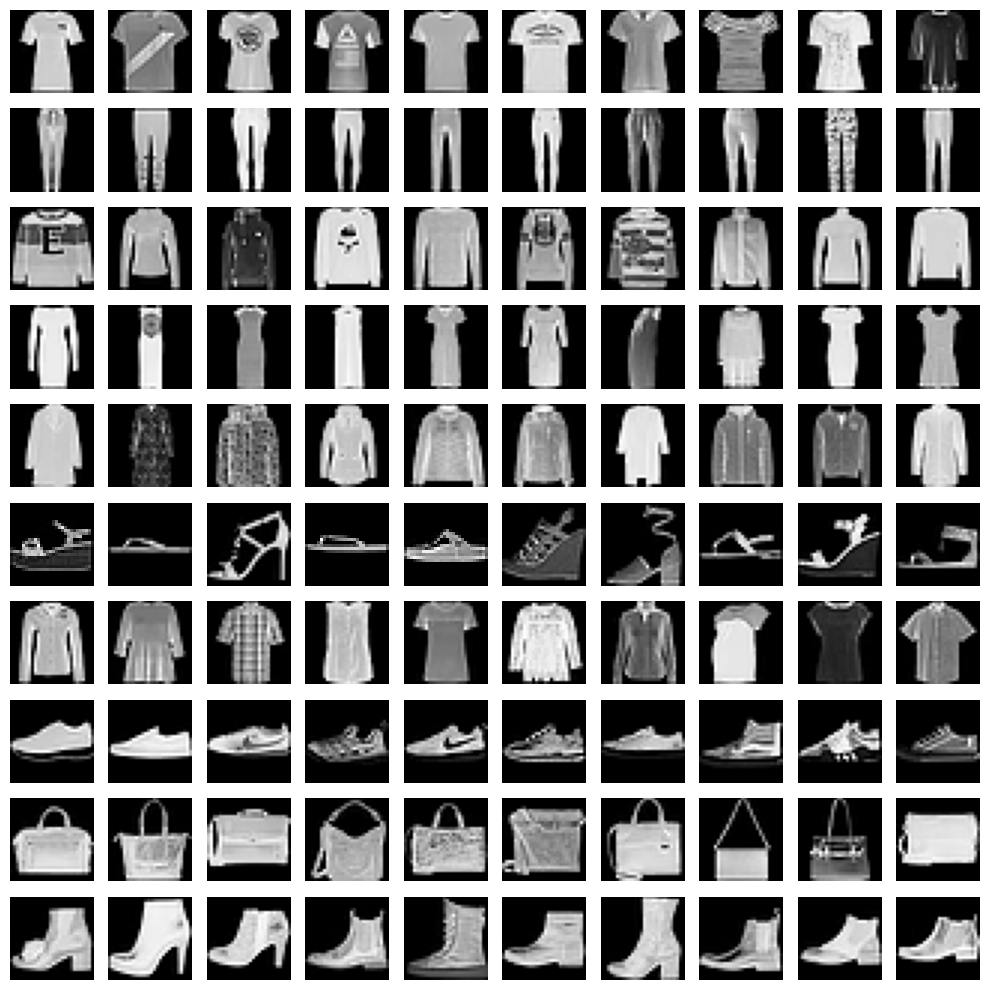

In [6]:
# R 表示数据集中类别的数量（通过去重 tr_targets.unique() 得到，例如 10 类）
# C 设置为 10，表示每一类展示 10 张样本图
R, C = len(tr_targets.unique()), 10
# 创建绘图窗口和子图区域：
# 会生成 R 行 × C 列的子图网格（例如 10×10）
# figsize=(10,10) 设置整张图的大小
fig, ax = plt.subplots(R, C, figsize=(10,10))
# 遍历每一行（每一类标签对应一行）
# enumerate(ax) 会返回 (label_class, plot_row)
# label_class 是类别编号（0 ~ 9），plot_row 是该行的子图对象数组
for label_class, plot_row in enumerate(ax):
    # 找到所有属于当前类别 (label_class) 的样本索引
    # np.where(tr_targets == label_class)[0] 返回的是索引数组
    label_x_rows = np.where(tr_targets == label_class)[0]
    # 遍历当前行的每一个小图格子
    for plot_cell in plot_row:
        # 去掉网格和坐标轴显示
        plot_cell.grid(False)
        plot_cell.axis('off')
        # 从当前类别的样本索引里随机挑选一张图片
        ix = np.random.choice(label_x_rows)
        # 根据索引获取图片和标签
        x, y = tr_images[ix], tr_targets[ix]
        # 把图片显示到子图里，灰度模式（cmap='gray'）
        plot_cell.imshow(x, cmap='gray')
# 调整子图之间的间距，避免重叠
plt.tight_layout()


## 第三章 第五节 训练神经网络   steps to build a neural network on FashionMNIST